In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

In [3]:
job_cards = soup.find_all("div", class_="card-content")

len(job_cards)

100

In [5]:
base_url = "https://realpython.github.io"

job_links = []

for job in job_cards:
    
    link = job.find("a", string="Apply")["href"]
    
    if link.startswith("/"):
        link = base_url + link
        
    job_links.append(link)

print(job_links[:5])

['https://realpython.github.io/fake-jobs/jobs/senior-python-developer-0.html', 'https://realpython.github.io/fake-jobs/jobs/energy-engineer-1.html', 'https://realpython.github.io/fake-jobs/jobs/legal-executive-2.html', 'https://realpython.github.io/fake-jobs/jobs/fitness-centre-manager-3.html', 'https://realpython.github.io/fake-jobs/jobs/product-manager-4.html']


In [6]:
job_descriptions = []

for link in job_links:

    page = requests.get(link)
    soup = BeautifulSoup(page.text, "html.parser")

    desc = soup.find("div", class_="content")

    if desc:
        job_descriptions.append(desc.get_text().lower())
    else:
        job_descriptions.append("")

In [7]:
job_descriptions[0][:500]

'\nprofessional asset web application environmentally friendly detail-oriented asset. coordinate educational dashboard agile employ growth opportunity. company programs css explore role. html educational grit web application. oversea scrum talented support. web application fast-growing communities inclusive programs job css. css discussions growth opportunity explore open-minded oversee. css python environmentally friendly collaborate inclusive role. django no experience oversee dashboard environm'

In [8]:
len(job_descriptions)

100

### Skill Keyword Analysis

To estimate technology demand, job descriptions were searched for common technical keywords including programming languages and tools.

In [9]:
skills = [
    "python",
    "sql",
    "javascript",
    "java",
    "c++",
    "aws",
    "docker",
    "react",
    "node",
    "mongodb",
    "postgresql",
    "mysql",
    "excel",
    "power bi"
]

In [10]:
skill_counts = {}

for skill in skills:
    
    count = sum(skill in desc for desc in job_descriptions)
    
    skill_counts[skill] = count

skill_counts

{'python': 5,
 'sql': 0,
 'javascript': 0,
 'java': 6,
 'c++': 0,
 'aws': 0,
 'docker': 0,
 'react': 0,
 'node': 0,
 'mongodb': 0,
 'postgresql': 0,
 'mysql': 0,
 'excel': 0,
 'power bi': 0}

In [11]:
df_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Frequency"]
)

df_skills = df_skills.sort_values(by="Frequency", ascending=False)

df_skills

,Skill,Frequency
3,java,6
0,python,5
1,sql,0
2,javascript,0
4,c++,0
5,aws,0
6,docker,0
7,react,0
8,node,0
9,mongodb,0


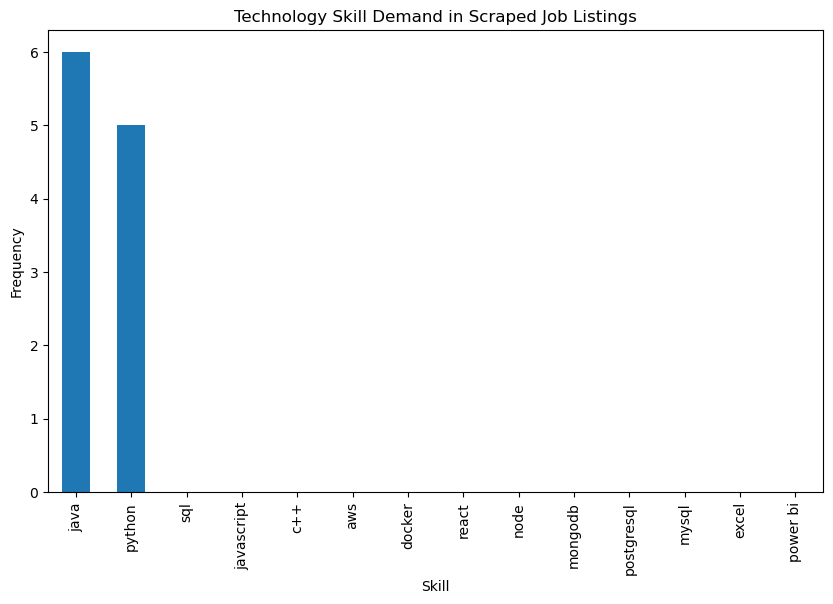

In [12]:
df_skills.plot(
    x="Skill",
    y="Frequency",
    kind="bar",
    figsize=(10,6),
    legend=False
)

plt.title("Technology Skill Demand in Scraped Job Listings")
plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.show()

In [13]:
df_skills.to_csv("job_skill_demand_scraped.csv", index=False)

## Conclusion

Web scraping enabled the collection of job listing data from a public job board.  
By analyzing job descriptions, commonly requested technologies were identified.

